# Autoencoders 

- AE Overview: https://lilianweng.github.io/posts/2018-08-12-vae/
- VAE: https://arxiv.org/abs/1906.02691
- ELBO: https://yunfanj.com/blog/2021/01/11/ELBO.html

## Notes
- **Autoencoders** (AE) are trained to reconstruct high-dimensional data. We do not care about the reconstructed data (we already had it) but we do care about the inner representation that it uses for this task.
    - Usually this latent encoding is smaller than the original data. Can be used for data compression or something like search.
- The AE consists of two networks:
    - *Encoder*: "translates the original high-dimension input into the latent low-dimensional code" (Weng)
    - *Decoder*: "...recovers the data from the code, likely with larger and larger output layers." (Weng)
- To train an AE we can just use MSE between the input and the reconstructed input.
- This is like a more powerful PCA.
- If there are more weights than data points, the model can just create a meaningless bijection using the weights that just memorizes the input and doesn't represent its information.
- To remedy this we can use a **Denoising AE** which adds some noise to the inputs before learning to encode/decode the information. The model is trained to reconstruct the non-noisy input.
- There is a sparsity penalty term that "tells" the network to use fewer neurons per layer, ensuring robustness. This is efficient for overcomplete AE where the hidden layer is larger than input layer.

#### VAE

- For **Variational AE** (VAE) we don't represent the data as a vector, but rather as a distribution $p_\theta$
- The broad goal of a VAE is to find the distribution $p(x)$ of the input.
- We have a latent representation $z$. That $z$ is also used to generate our outputs
- $x \to z$ is compression, $z \to x$ is the generative process
- We have our encoder $q_\phi (z|x)$ which in theory gives us a distribution of all possible embeddings $z$. In reality, that is very impractical, so instead it outputs the parameters needed for a distribution (mostly Gaussians)
    - If we have a hidden dimension of a 100, our encoder will be a Gaussian distribution with 100 means and 100 variances
- Then we sample from the distribution and use a decoder network to parameterize the distribution for output $x$
- Once we have a trained VAE we can use it as a generative model. We sample from the latent space (get a random $z$) and the decoder should output new data that looks comparable to actual data we used for training. 
- The objective function that is used to train VAEs is **Evidence Lower Bound (ELBO)**

##### ELBO

- $p_\theta (x)$ is the probability of an input that our model assigns them. We are looking for this number to be as high as possible. We never calculate this value explicitly (we can't, its a complex integral), but the entire VAE is structured to maximize this value.
    - $p(x) = \int_z p(x|z)p(z)dz$ which is "intractable" to solve for continuous $z$. I question why this can't be approximated.
- To find $p(x)$ we condition it on some $z$ where we assume that $p(z)$ is some nice distribution like Bernouili or Gaussian. We then just need to find $p(x|z)$ (the decoder) which we use a NN for.
- Through some convoluted substituions and what-not we have: $log \space p_\theta (x)= \underbrace{\mathbb{E}_{q_{\phi}(\mathbf{z}|\mathbf{x})} \left[ \log \left[ \frac{p_{\theta}(\mathbf{x}, \mathbf{z})}{q_{\phi}(\mathbf{z}|\mathbf{x})} \right] \right]}_{\mathcal{L}_{\theta,\phi}(\mathbf{x}) \text{ (ELBO)}} + \underbrace{\mathbb{E}_{q_{\phi}(\mathbf{z}|\mathbf{x})} \left[ \log \left[ \frac{q_{\phi}(\mathbf{z}|\mathbf{x})}{p_{\theta}(\mathbf{z}|\mathbf{x})} \right] \right]}_{D_{KL}(q_{\phi}(\mathbf{z}|\mathbf{x}) || p_{\theta}(\mathbf{z}|\mathbf{x}))}$
    - The second term is KL divergence which measures the difference between two distributions, in this case between the encoder and the true encoded distribution
    - The first term is the objective function that we are trying to minimize, aka ELBO.
-  We have $\mathcal{L} = log \space p_\theta(x)-D_{KL}(\dots)$ and since KL is non-negative $\mathcal{L} \leq log \space p_\theta (x)$.
    -  Hence the "lower bound" in the name
- The most common way of writing this is $\mathcal{L} = \mathbb{E}_{z \sim q_{\phi}(z|x)} [\log p_{\theta}(x|z)] - D_{KL}(q_{\phi}(z|x) || p(z))$
    - The first term measures how likely we are to recreate the original image. Second term measures how far off our model deviates from the distribution for $z$ that we set at the start (prevents memorization)
    - We maximize this (or rather minimize $-\mathcal{L}$)
- Since we sample from a distribution, the backprop chain is broken. To address this we use a **parameterization trick**
    - We redefine $z$ to be more or less determinate with $z = \mu + \sigma \odot \epsilon$ where $\epsilon \sim \mathcal{N}(0,1)$




## Code
We will implement and train a simple VAE on the MNIST dataset and then use the decoder to create brand new images.

In [9]:
import torch
import torch.nn as nn
from torch.distributions import Normal
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn.functional as F
import numpy as np

In [21]:
class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(28*28, 256),
                                     nn.ReLU(),
                                     nn.Linear(256,128),
                                     nn.ReLU(),
                                     nn.Linear(128, 64))
        
        self.decoder = nn.Sequential(nn.Linear(32, 128),
                                     nn.ReLU(),
                                     nn.Linear(128,256),
                                     nn.ReLU(),
                                     nn.Linear(256, 28*28))

    def forward(self, x):
        x = x.view(-1,28*28)
        params = self.encoder(x)

        logvar = params[:, 32:]
        mu = params[:, :32]
        std = torch.exp(0.5 * logvar)

        z = mu + std * torch.randn_like(logvar)
        x_hat = self.decoder(z)

        return x_hat, mu, logvar, z

    # AI generated
    def ELBO(self, x, x_hat, mu, logvar, z):
        #  first term in ELBO
        reconstruction_loss = F.mse_loss(x_hat, x.view(-1,28*28), reduction="sum")
        
        std = torch.exp(0.5 * logvar)
        q_dist = Normal(mu, std)
        
        p_dist = Normal(torch.zeros_like(mu), torch.ones_like(std))

        # KL = log(q(z)) - log(p(z))
        log_q_zx = q_dist.log_prob(z).sum(dim=1)
        log_p_z = p_dist.log_prob(z).sum(dim=1)
        
        kld_loss = torch.sum(log_q_zx - log_p_z)
    
        return reconstruction_loss + kld_loss
        

In [12]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = datasets.MNIST(
    root='../data', 
    train=True, 
    transform=transform, 
    download=True
)

test_dataset = datasets.MNIST(
    root='../data', 
    train=False, 
    transform=transform, 
    download=True
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

In [22]:
model = VAE()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

def train(epoch):
    model.train()
    train_loss = 0
    
    for batch_idx, (data, _) in enumerate(train_loader):
        optimizer.zero_grad()
        
        x_hat, mu, logvar, z = model(data)
        
        loss = model.ELBO(data, x_hat, mu, logvar, z)
        
        loss.backward()
        train_loss += loss.item()
        
        optimizer.step()
        
    print(f'Epoch {epoch + 1}: Average Loss: {train_loss / len(train_loader.dataset):.4f}')

for epoch in range(10):
    train(epoch)

Epoch 1: Average Loss: 50.8380
Epoch 2: Average Loss: 41.0244
Epoch 3: Average Loss: 36.0901
Epoch 4: Average Loss: 34.7633
Epoch 5: Average Loss: 34.0540
Epoch 6: Average Loss: 33.5767
Epoch 7: Average Loss: 33.2030
Epoch 8: Average Loss: 32.9153
Epoch 9: Average Loss: 32.6982
Epoch 10: Average Loss: 32.4971


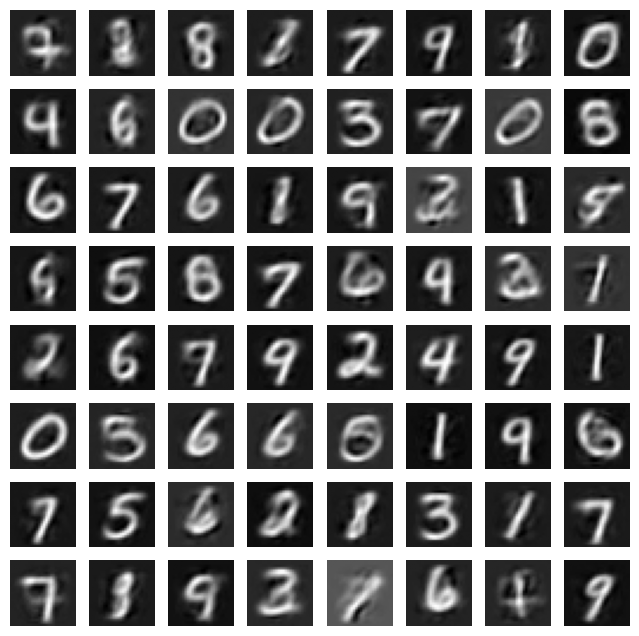

In [23]:
import matplotlib.pyplot as plt

def generate_digits(model, num_samples=64):
    model.eval()
    
    with torch.no_grad():
        z_samples = torch.randn(num_samples, 32)
        
        recon_images = model.decoder(z_samples)
        
        recon_images = recon_images.view(-1, 28, 28)
        
    plt.figure(figsize=(8, 8))
    for i in range(num_samples):
        plt.subplot(8, 8, i+1)
        plt.imshow(recon_images[i].cpu().numpy(), cmap='gray')
        plt.axis('off')
    plt.show()

generate_digits(model)